# 8. The method of least squares

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt 
import math
from sklearn.linear_model import LinearRegression
import seaborn as sns

ДЗ 1.а

In [3]:
df_cherry_measurements = pd.read_excel('measurements_black_cherry_trees.xlsx')

𝑦 и 𝑑^2ℎ   объективная причина - геометрия, V=PR^2*H 
R-линейно зависима от 𝑑
H и есть ℎ

In [4]:
df_cherry_measurements

,Diameter,Height,Volume
0,0.21,21.3,0.29
1,0.22,19.8,0.29
2,0.22,19.2,0.29
3,0.27,21.9,0.46
4,0.27,24.7,0.53
5,0.27,25.3,0.56
6,0.28,20.1,0.44
7,0.28,22.9,0.52
8,0.28,24.4,0.64
9,0.28,22.9,0.56


Text(0.5, 0, 'd^2ℎ')

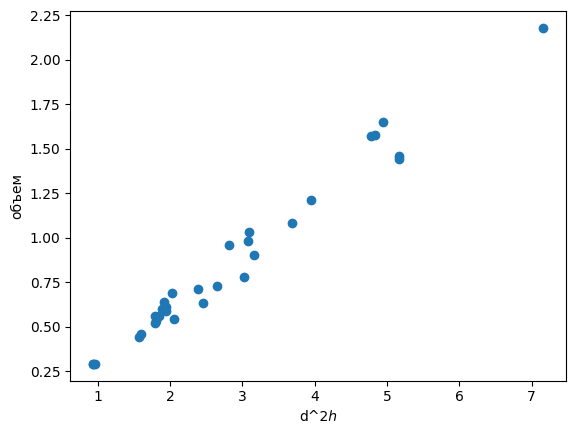

In [5]:
xs = []
for i in range(len(df_cherry_measurements['Diameter'])):
    xs.append(df_cherry_measurements['Diameter'][i]**2 * df_cherry_measurements['Height'][i])
plt.scatter(x=xs, y=df_cherry_measurements['Volume'])
plt.ylabel("объем")
plt.xlabel("d^2ℎ")

средний наклон = 0.3024611199883203
наклон средних значений = 0.3032032103384744


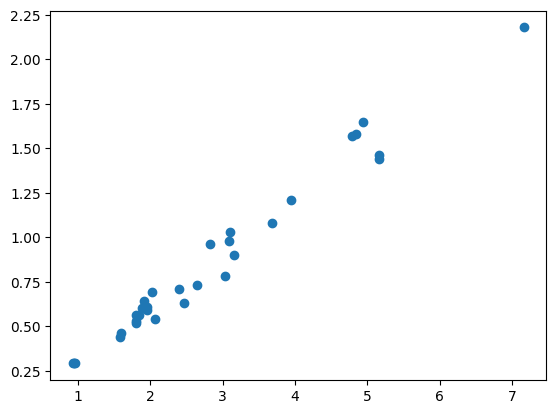

In [25]:
z = []

for i in range(len(df_cherry_measurements['Diameter'])):
    z.append(df_cherry_measurements['Volume'][i] / (df_cherry_measurements['Diameter'][i]**2 * df_cherry_measurements['Height'][i]))

z_mean = np.mean(z)
yx_mean = np.mean(df_cherry_measurements['Volume']) / np.mean(xs)
model = LinearRegression()
model.fit(np.array(xs).reshape(-1, 1), df_cherry_measurements['Volume'].values)
y_pred = model.predict(np.array(xs).reshape(-1, 1))

print('средний наклон =', z_mean)
print('наклон средних значений =', yx_mean)

plt.scatter(x=xs, y=df_cherry_measurements['Volume'])

In [20]:
reshaped_x = np.array(xs).reshape(-1, 1)

model = LinearRegression()
model.fit(reshaped_x, df_cherry_measurements['Volume'])
y_pred = model.predict(reshaped_x)
print('Slope: {:.3f}'.format(model.coef_[0]))
print('Intercept: {:.3f}'.format(model.intercept_))

slope_least_squares = model.coef_[0]

Slope: 0.308
Intercept: -0.012


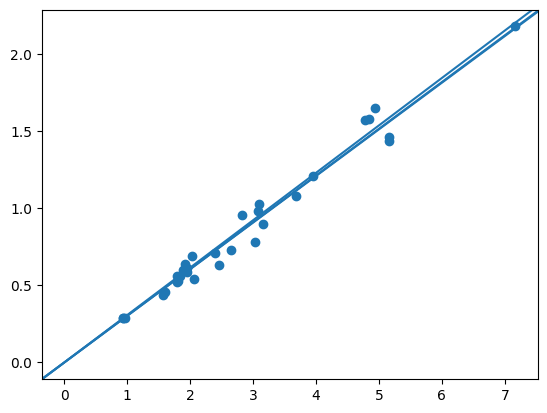

In [26]:
plt.axline((0, 0), slope=z_mean)
plt.axline((0, 0), slope=yx_mean)
plt.axline((0, 0), slope=slope_least_squares)
plt.scatter(x=xs, y=df_cherry_measurements['Volume'])